# **Part 3**

##1. Text Preparation, Tokenization, and Sequence Alignment

1.1 Mount, Load, Clean, and Visualize Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
file_path = '/content/drive/Shareddrives/AI and ML Final CourseWork/1. Book Review Dataset/Book_review.csv'
df = pd.read_csv(file_path)

print("Initial data preview:")
display(df.head())

Initial data preview:


,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [ ]:
df = df[['rating', 'reviewText']]

df.rename(columns={'reviewText': 'review'}, inplace=True)

print("DataFrame initial look:")
display(df.head())
print("DataFrame dimensions:", df.shape)

DataFrame initial look:


,rating,review
0,5,This book was the very first bookmobile book I...
1,1,"When I read the description for this book, I c..."
2,5,I just had to edit this review. This book is a...
3,5,I don't normally buy 'mystery' novels because ...
4,5,"This isn't the kind of book I normally read, a..."


DataFrame dimensions: (12000, 2)


The dataset contains columns like `summary` and an `unnamed index`.

However, for analyzing sentiment:
*   We only need the `reviewText`.
*   The `rating` will become our sentiment label.

Keeping extra columns would:
*   Make things more confusing.
*   Make the cleaning process messier.

## Generating Sentiment Labels

In [ ]:
def sentiment_label(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(sentiment_label)

print("Sentiment category distribution:")
print(df["sentiment"].value_counts())

Sentiment category distribution:
sentiment
positive    6000
negative    4000
neutral     2000
Name: count, dtype: int64


Deep learning models need labels to classify things.

We change the original ratings into these sentiment labels:
*   Negative
*   Neutral
*   Positive

This setup creates a task called:

**Multiclass Sentiment Classification** (where the model picks one of three feelings).

## Displaying Sentiment Distribution

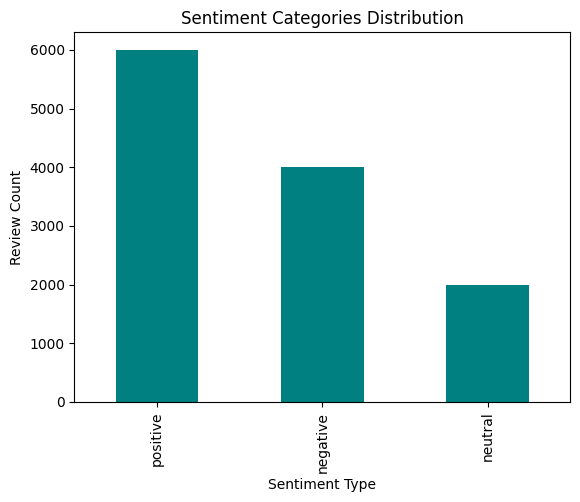

In [ ]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar", color='teal')

plt.title("Sentiment Categories Distribution")
plt.xlabel("Sentiment Type")
plt.ylabel("Review Count")
plt.show()

## Importing NLP Libraries

In [ ]:
import re
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Here's what each library helps us do:

*   `re`: Used for cleaning and finding patterns in text.
*   `stopwords`: Helps remove common words (like 'the', 'is', 'a') that don't add much meaning.
*   `lemmatizer`: Changes words to their basic form (e.g., 'running' becomes 'run').

## Create Stopwords & Lemmatizer

In [ ]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

## Creating a Text Cleaning Function

In [ ]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.translate(str.maketrans('', '', string.punctuation))


    words = text.split()
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            lemma_word = lemmatizer.lemmatize(word)
            cleaned_words.append(lemma_word)

    return " ".join(cleaned_words)

df['clean_review'] = df['review'].apply(clean_text)

print("Original vs. Cleaned Reviews (first 5 entries):")
display(df[['review', 'clean_review']].head())

Original vs. Cleaned Reviews (first 5 entries):


,review,clean_review
0,This book was the very first bookmobile book I...,book first bookmobile book bought school book ...
1,"When I read the description for this book, I c...",read description book couldnt wait read downlo...
2,I just had to edit this review. This book is a...,edit review book believe got right updated rew...
3,I don't normally buy 'mystery' novels because ...,dont normally buy mystery novel dont like howe...
4,"This isn't the kind of book I normally read, a...",isnt kind book normally read although try limi...


## Pre- vs. Post-Processing Comparison

In [ ]:
for i in range(3):

    print("\n--- Original Review ---\n")
    print(df['review'][i])

    print("\n--- Processed Review ---\n")
    print(df['clean_review'][i])

    print("\n" + "="*100)


--- Original Review ---

This book was the very first bookmobile book I bought when I was in the school book club. I loved the story then and I bet a dollar to a donut I will love it again. If my memory serves, I bought this book in 5th grade. That would have been about 1961. I am looking forward to reliving the memories.

--- Processed Review ---

book first bookmobile book bought school book club loved story bet dollar donut love memory serf bought book th grade would looking forward reliving memory


--- Original Review ---

When I read the description for this book, I couldn't wait to read it. Once I downloaded it to my Kindle, I found it extremely hard to keep reading it.  To be honest, I stopped reading halfway through the book. It began slow and remained a slow, uninteresting read.  It lacked passion; not making love passion, but passion for life. Neither Jada or Aaron were interesting characters and the story was too, too `everything is perfect'.  Everybody is just so understa

## Visualizing Cleaned Text

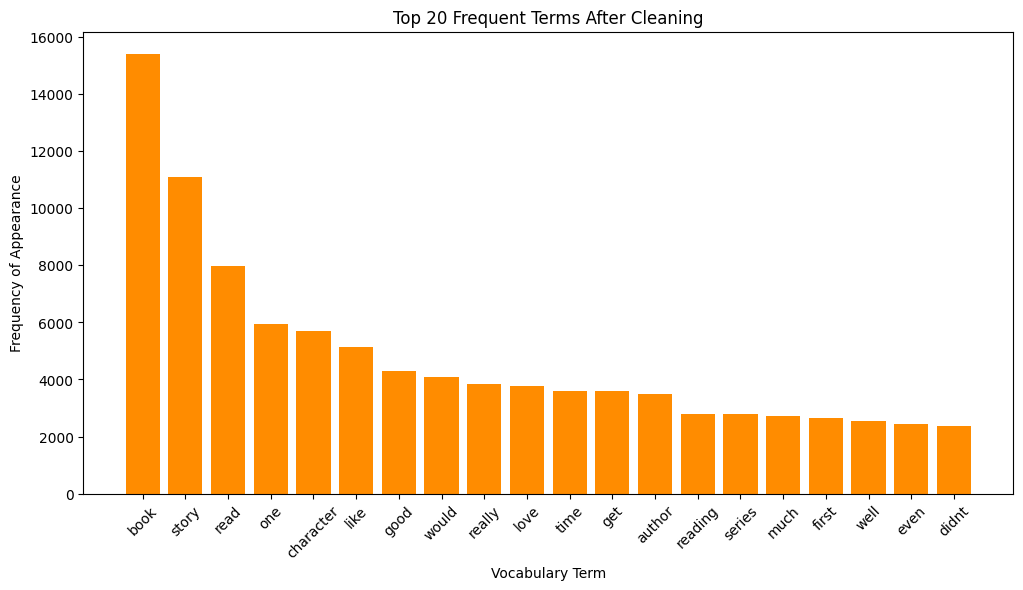

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

all_words = " ".join(df["clean_review"]).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='darkorange')
plt.title("Top 20 Frequent Terms After Cleaning")
plt.xlabel("Vocabulary Term")
plt.ylabel("Frequency of Appearance")
plt.xticks(rotation=45)
plt.show()

This chart shows which words appear most often after we cleaned the text. It's useful for your report because it proves you looked closely at the cleaned data.

## Preparing Labels for Model Training

In [ ]:
from tensorflow.keras.utils import to_categorical

label_mapping = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["sentiment"].map(label_mapping)

y = to_categorical(df["label"], num_classes=3) # Convert labels to one-hot encoding

Our model will have 3 output units (neurons), one for each sentiment:

*   Negative
*   Neutral
*   Positive

So, the sentiment labels also need to be changed into this 3-part format to match the model's output.

## Data Split: Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
Y = y

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df["label"] # Ensure balanced sentiment distribution
) # Split data into training and testing sets

We use 80% of the data for training our model and 20% for testing it.

The `stratify` option makes sure that both the training and testing groups have a similar mix of positive, neutral and negative reviews.

## Generating the Embedding Matrix

## Text Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 5000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test) # Convert text to sequences

word_index = tokenizer.word_index

print("Total vocabulary size:", len(word_index))
print("First training text example (raw):", X_train.iloc[0])
print("First training text example (tokenized preview):", X_train_seq[0][:20])

Total vocabulary size: 36167
First training text example (raw): ok im always starting series book wrong order read first nd book series seems reading taming eliza jane next surethe moment rebecca step stage adam greet immediately feel web attraction thats good shannon writing isthe biting word shared part elaborate dance reader feel wont last long rebecca determined let hair speak cut loose wild west town held check sheriff adamthat somewhat reputation shoot first ask question laterhis deputy newly married eliza jane constantly running adam figure time maybe take nice sweet wife like rebeccca boy surprise start dressing clothes aunt left along house ill reputeyes madam virginal one dare ask adam firstof course adam doesnt like revealing clothes face paintespecially look get men asks everyone call miss becky come unglued well seems miss becky good reason incognitothe suspense bible brigade elizas liberated woman adam bumbling courtship oh will bubble bath wifethis story actually lot sto

Computers and neural networks can't directly understand words.

Tokenization changes words into numbers. For example: `book amazing story` might become `[12, 45, 89]`.

## Percentile-Based Sequence Padding

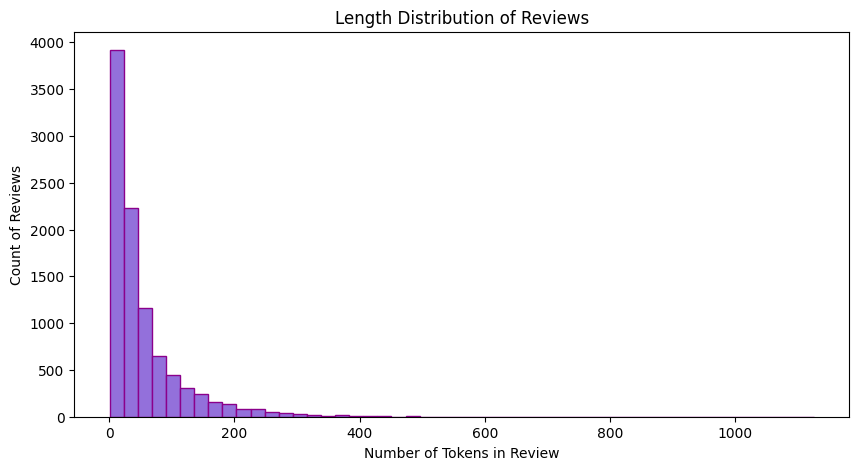

Calculated 95th percentile sequence length: 183


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

review_lengths = [len(seq) for seq in X_train_seq]

plt.figure(figsize=(10, 5))
plt.hist(review_lengths, bins=50, color='mediumpurple', edgecolor='darkmagenta')
plt.title("Length Distribution of Reviews")
plt.xlabel("Number of Tokens in Review")
plt.ylabel("Count of Reviews")
plt.show()

MAX_LEN = int(np.percentile(review_lengths, 95)) # Determine max sequence length for padding
print("Calculated 95th percentile sequence length:", MAX_LEN)

## Visualization: Word Cloud

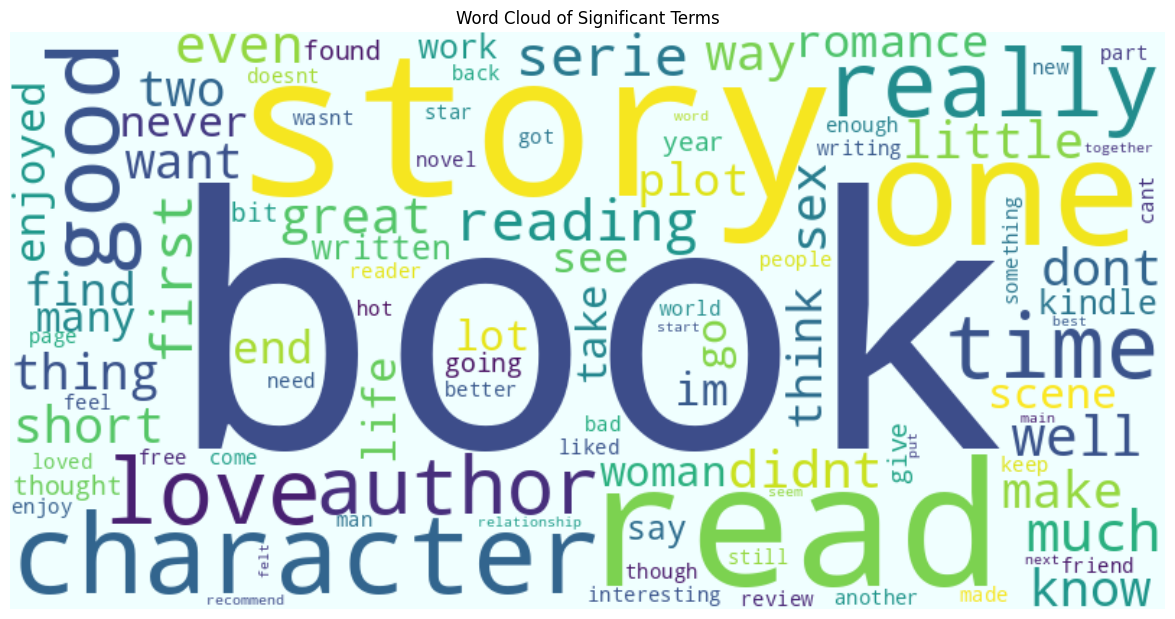

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Join all cleaned reviews into one string
text = ' '.join(df['clean_review'])

# Default stopwords
custom_stopwords = set(STOPWORDS)

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='azure',
    stopwords=custom_stopwords,
    max_words=100,
    collocations=False
).generate(text)

# Display word cloud
plt.figure(figsize=(15, 7.5))

plt.imshow(wc, interpolation='bilinear')

plt.axis('off')

plt.title('Word Cloud of Significant Terms')

plt.show()

This histogram is helpful because it shows:

*   Most reviews are short or medium-sized.
*   Only a few reviews are very long.

This is why we use 'percentile padding' – it helps us choose a good length without making all reviews too long.

In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Shape of padded training sequences:", X_train_pad.shape)
print("Shape of padded test sequences:", X_test_pad.shape)

Shape of padded training sequences: (9600, 183)
Shape of padded test sequences: (2400, 183)


RNN and LSTM models need all their input texts to be the same length.

Padding makes sure every review has the same number of tokens.

Using the 95th percentile (meaning 95% of reviews are shorter than this length) is better than picking a random length. This avoids making all reviews super long, which would waste training time.

## Constructing a Simple RNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

EMBEDDING_DIM = 128

rnn_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    SimpleRNN(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
]) # Define the Simple RNN model

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 183, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,531 (2.50 MB)

 Trainable params: 654,531 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training Phase

In [ ]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()
        self.total_time = 0

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        print(f" - Epoch duration: {elapsed:.1f} seconds")
        self.epoch_times.append(elapsed)

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

time_cb = TimeHistory()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, time_cb]
)

print(f"\nOverall training duration: {time_cb.total_time:.1f} seconds")

Epoch 1/15
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4641 - loss: 1.0427 - Epoch duration: 9.1 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.4845 - loss: 1.0325 - val_accuracy: 0.5005 - val_loss: 1.0053
Epoch 2/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5061 - loss: 1.0122 - Epoch duration: 3.6 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5057 - loss: 1.0077 - val_accuracy: 0.5005 - val_loss: 1.0180
Epoch 3/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4882 - loss: 1.0245 - Epoch duration: 3.7 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4814 - loss: 1.0335 - val_accuracy: 0.5016 - val_loss: 1.0129
Epoch 4/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4833 - loss: 1.0341 - Epoch duration: 4.0 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4863 - loss: 1.0287 - val_accuracy: 0.5016 - val_loss: 1.0108

Overall training duration: 20.5 seconds


## Model Performance Evaluation

In [ ]:
rnn_loss, rnn_acc = rnn_model.evaluate(
    X_test_pad,
    y_test
)

print("Simple RNN Model Test Accuracy:", rnn_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4975 - loss: 1.0132
Simple RNN Model Test Accuracy: 0.4975000023841858


## Plotting Training Graphs

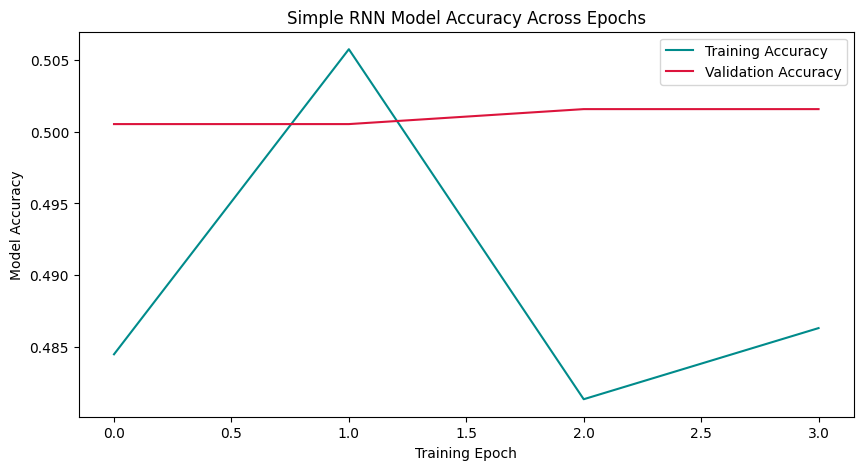

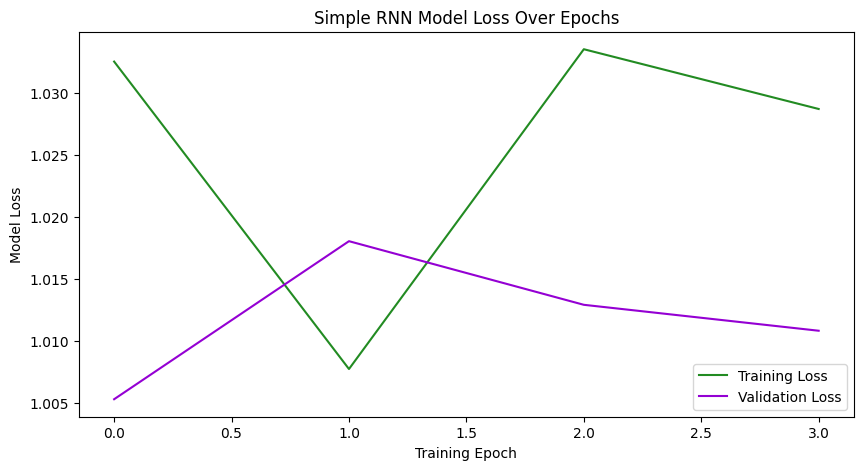

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['accuracy'], label='Training Accuracy', color='darkcyan')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy', color='crimson')

plt.title("Simple RNN Model Accuracy Across Epochs")
plt.xlabel("Training Epoch")
plt.ylabel("Model Accuracy")

plt.legend()

plt.show()


plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='Training Loss', color='forestgreen')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss', color='darkviolet')

plt.title("Simple RNN Model Loss Over Epochs")
plt.xlabel("Training Epoch")
plt.ylabel("Model Loss")

plt.legend()

plt.show()

## Building a Bidirectional LSTM with Trainable Embeddings

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

lstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(3, activation='softmax')
]) # Define the Bidirectional LSTM model

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary(
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 183, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,267 (2.85 MB)

 Trainable params: 747,267 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

## Bidirectional LSTM Model Training

In [ ]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

# 1. Define the timing callback class
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):

        elapsed = time.time() - self.epoch_start
        print(f" - Epoch duration: {elapsed:.1f} seconds")
        self.epoch_times.append(elapsed)

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

# 2. Instantiate both callbacks
time_cb = TimeHistory()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 3. Train the LSTM model
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, time_cb] # Pass both here
)

# 4. Report the results
print(f"\nOverall LSTM training duration: {time_cb.total_time:.1f} seconds")

Epoch 1/15
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5372 - loss: 0.9705 - Epoch duration: 12.5 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.6220 - loss: 0.8727 - val_accuracy: 0.7047 - val_loss: 0.7412
Epoch 2/15
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7447 - loss: 0.6408 - Epoch duration: 4.3 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7553 - loss: 0.6267 - val_accuracy: 0.7177 - val_loss: 0.7062
Epoch 3/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8152 - loss: 0.4751 - Epoch duration: 4.3 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8107 - loss: 0.4898 - val_accuracy: 0.7026 - val_loss: 0.7923
Epoch 4/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8648 - loss: 0.3698 - Epoch duration: 5.6 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8553 - loss: 0.3904 - val_accuracy: 0.6969 - val_loss: 0.8732
Epoch 5/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc

## Evaluating LSTM Performance

In [ ]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test_pad,
    y_test
)

print("LSTM Model Test Accuracy:", lstm_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7196 - loss: 0.6859
LSTM Model Test Accuracy: 0.7195833325386047


## LSTM Performance Graphs

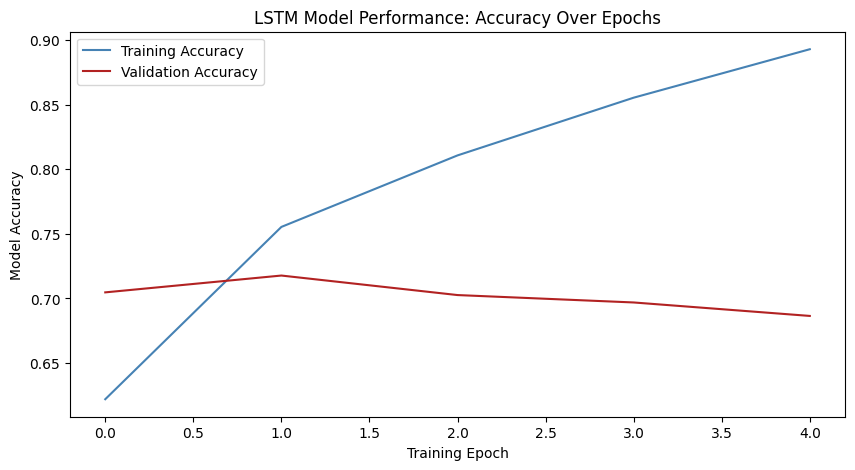

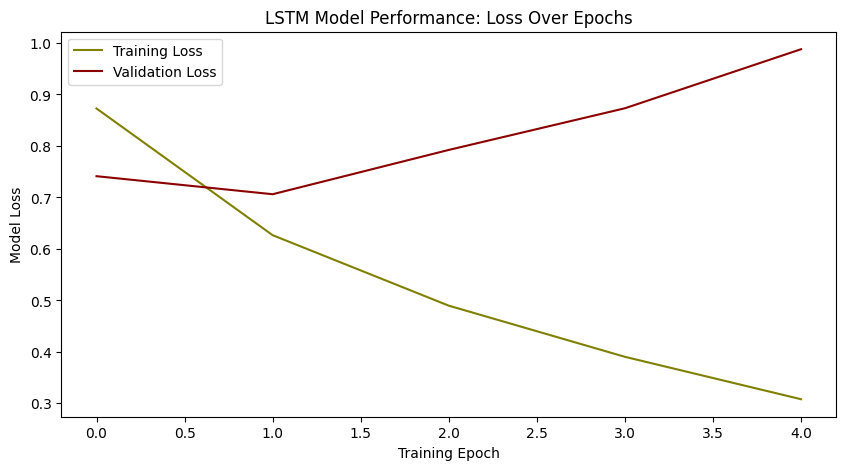

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['accuracy'], label='Training Accuracy', color='steelblue')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', color='firebrick')

plt.title("LSTM Model Performance: Accuracy Over Epochs")
plt.xlabel("Training Epoch")
plt.ylabel("Model Accuracy")

plt.legend()

plt.show()


plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='Training Loss', color='olive')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss', color='darkred')

plt.title("LSTM Model Performance: Loss Over Epochs")
plt.xlabel("Training Epoch")
plt.ylabel("Model Loss")

plt.legend()

plt.show()

Compared to the Simple RNN model, the LSTM model had:

*   Higher accuracy on new data (validation accuracy).
*   A clearer path of improvement during training.
*   More stable results overall.

## Installing Gensim Library

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.1 MB/s eta 0:00:00


## Loading Pre-trained Word Embeddings

We are using GloVe 50D word embeddings. This specific version is chosen because it's smaller and works faster in Colab.

In [ ]:
import gensim.downloader as api

embedding_model = api.load("glove-wiki-gigaword-50") # Load pre-trained GloVe word embeddings

[==================================================] 100.0% 66.0/66.0MB downloaded


Instead of having our model learn the meaning of words from scratch, these pre-trained embeddings already know how words relate to each other from a huge collection of text.

For example:

1.  Words like 'good', 'great' and 'excellent' are seen as similar.
2.  Words like 'bad', 'boring' and 'poor' are also understood to be related.

## Create embedding matrix

In [ ]:
import numpy as np

EMBEDDING_DIM = 50

word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word] # Populate embedding matrix

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (5000, 50)


This process creates a special table (matrix) where:

1.  Each row represents a single word.
2.  Each column holds numbers that describe the meaning or features of that word.

## Building the Word2Vec/GloVe LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

word2vec_lstm = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False # Use fixed pre-trained embeddings
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
]) # Define the LSTM model with pre-trained embeddings

word2vec_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

word2vec_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 183, 50)        │       250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,619 (1.07 MB)

 Trainable params: 31,619 (123.51 KB)

 Non-trainable params: 250,000 (976.56 KB)

We set `trainable=False` for a reason:

Because we're using word vectors that have already learned word meanings from a different large dataset. We keep them fixed so our model uses this existing knowledge and doesn't try to change these already good word representations.

## Training the Word2Vec/GloVe LSTM

In [ ]:
import time
from tensorflow.keras.callbacks import Callback, EarlyStopping

class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.train_start = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start
        print(f" - Epoch duration: {elapsed:.1f} seconds")
        self.epoch_times.append(elapsed)

    def on_train_end(self, logs=None):
        self.total_time = time.time() - self.train_start

time_cb = TimeHistory()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_word2vec = word2vec_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, time_cb]
) # Train the Word2Vec/GloVe LSTM model with early stopping

print(f"\nOverall Word2Vec/GloVe LSTM training duration: {time_cb.total_time:.1f} seconds")

Epoch 1/15
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4850 - loss: 1.0422 - Epoch duration: 9.7 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.4957 - loss: 1.0251 - val_accuracy: 0.5016 - val_loss: 1.0026
Epoch 2/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4990 - loss: 1.0159 - Epoch duration: 7.5 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.4990 - loss: 1.0150 - val_accuracy: 0.5026 - val_loss: 1.0047
Epoch 3/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5097 - loss: 1.0044 - Epoch duration: 7.9 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.5003 - loss: 1.0128 - val_accuracy: 0.5026 - val_loss: 1.0044
Epoch 4/15
237/240 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5006 - loss: 1.0096 - Epoch duration: 5.3 seconds
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5013 - loss: 1.0110 - val_accuracy: 0.5031 - val_loss: 1.0024
Epoch 5/15
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accu

## Model Evaluation

In [ ]:
word2vec_loss, word2vec_acc = word2vec_lstm.evaluate(
    X_test_pad,
    y_test
)

print("Word2Vec/GloVe-enhanced LSTM Test Accuracy:", word2vec_acc)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5017 - loss: 1.0092
Word2Vec/GloVe-enhanced LSTM Test Accuracy: 0.5016666650772095


## Plotting Model Graphs

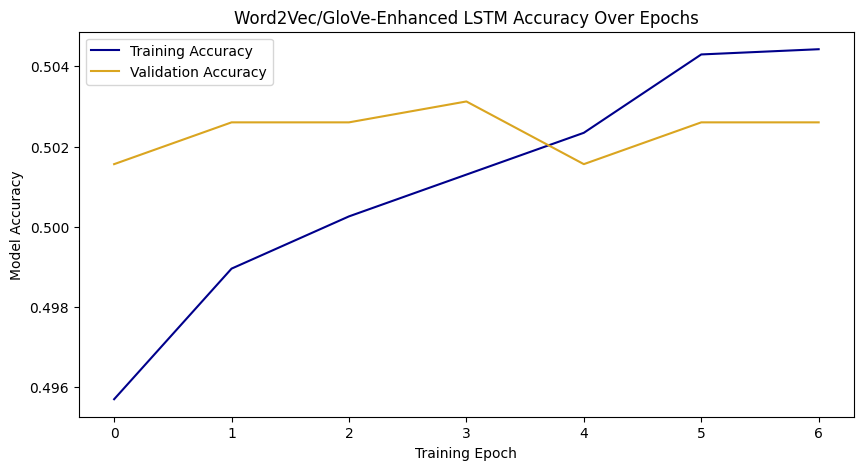

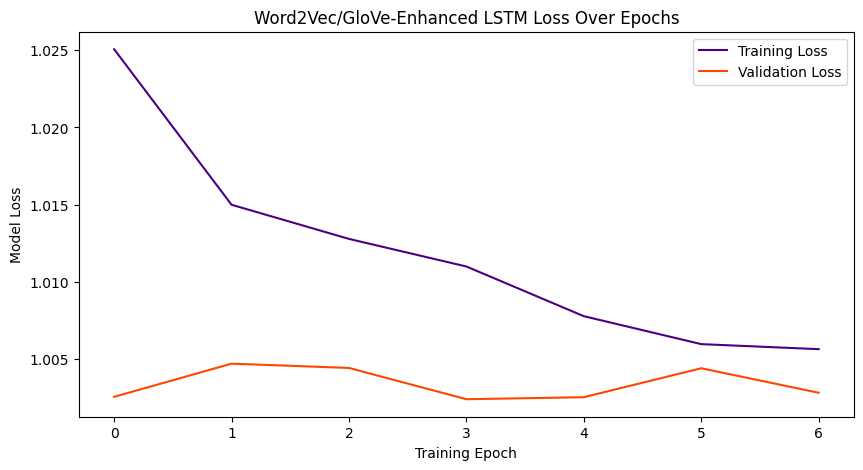

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_word2vec.history['accuracy'], label='Training Accuracy', color='darkblue')
plt.plot(history_word2vec.history['val_accuracy'], label='Validation Accuracy', color='goldenrod')
plt.title("Word2Vec/GloVe-Enhanced LSTM Accuracy Over Epochs")
plt.xlabel("Training Epoch")
plt.ylabel("Model Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history_word2vec.history['loss'], label='Training Loss', color='indigo')
plt.plot(history_word2vec.history['val_loss'], label='Validation Loss', color='orangered')
plt.title("Word2Vec/GloVe-Enhanced LSTM Loss Over Epochs")
plt.xlabel("Training Epoch")
plt.ylabel("Model Loss")
plt.legend()
plt.show()

## Model Predictions

In [ ]:
import numpy as np

rnn_pred = np.argmax(rnn_model.predict(X_test_pad), axis=1)
lstm_pred = np.argmax(lstm_model.predict(X_test_pad), axis=1)
word2vec_pred = np.argmax(word2vec_lstm.predict(X_test_pad), axis=1)

y_true = np.argmax(y_test, axis=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


## Classification Report

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

rnn_report = classification_report(
    y_true,
    rnn_pred,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

lstm_report = classification_report(
    y_true,
    lstm_pred,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

word2vec_report = classification_report(
    y_true,
    word2vec_pred,
    target_names=["Negative", "Neutral", "Positive"],
    output_dict=True
)

rnn_df = pd.DataFrame(rnn_report).transpose()
lstm_df = pd.DataFrame(lstm_report).transpose()
word2vec_df = pd.DataFrame(word2vec_report).transpose()

rnn_df = rnn_df.round(4)
lstm_df = lstm_df.round(4)
word2vec_df = word2vec_df.round(4)

print("--- RNN Performance Summary ---")
display(rnn_df)

print("\n--- LSTM Performance Summary ---")
display(lstm_df)

print("\n--- Word2Vec/GloVe LSTM Performance Summary ---")
display(word2vec_df)

--- RNN Performance Summary ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,precision,recall,f1-score,support
Negative,0.0000,0.0000,0.0000,800.0000
Neutral,0.0000,0.0000,0.0000,400.0000
Positive,0.4987,0.9950,0.6644,1200.0000
accuracy,0.4975,0.4975,0.4975,0.4975
macro avg,0.1662,0.3317,0.2215,2400.0000
weighted avg,0.2494,0.4975,0.3322,2400.0000



--- LSTM Performance Summary ---


,precision,recall,f1-score,support
Negative,0.7023,0.7875,0.7425,800.0000
Neutral,0.4000,0.1150,0.1786,400.0000
Positive,0.7572,0.8758,0.8122,1200.0000
accuracy,0.7196,0.7196,0.7196,0.7196
macro avg,0.6198,0.5928,0.5778,2400.0000
weighted avg,0.6794,0.7196,0.6834,2400.0000



--- Word2Vec/GloVe LSTM Performance Summary ---


,precision,recall,f1-score,support
Negative,0.6667,0.0050,0.0099,800.0000
Neutral,0.0000,0.0000,0.0000,400.0000
Positive,0.5013,1.0000,0.6678,1200.0000
accuracy,0.5017,0.5017,0.5017,0.5017
macro avg,0.3893,0.3350,0.2259,2400.0000
weighted avg,0.4728,0.5017,0.3372,2400.0000


## Confusion Matrix (LSTM Model)

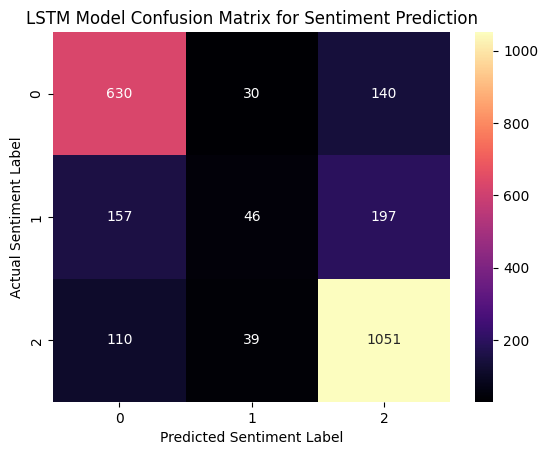

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, lstm_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='magma'
)

plt.title("LSTM Model Confusion Matrix for Sentiment Prediction")

plt.xlabel("Predicted Sentiment Label")
plt.ylabel("Actual Sentiment Label")

plt.show()

## Final Model Comparison Table

In [ ]:
import pandas as pd

results_df = pd.DataFrame({

    "Model": [
        "Simple RNN",
        "LSTM",
        "Word2Vec/GloVe + LSTM"
    ],

    "Test Accuracy": [
        rnn_acc,
        lstm_acc,
        word2vec_acc
    ]
})

results_df = results_df.round(4)

display(results_df)

,Model,Test Accuracy
0,Simple RNN,0.4975
1,LSTM,0.7196
2,Word2Vec/GloVe + LSTM,0.5017


## Comparative Performance Graph

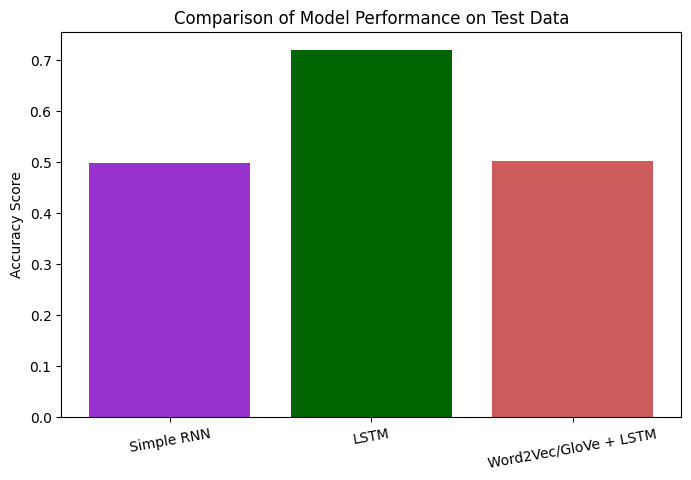

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Test Accuracy"],
    color=['darkorchid', 'darkgreen', 'indianred']
)

plt.title("Comparison of Model Performance on Test Data")

plt.ylabel("Accuracy Score")

plt.xticks(rotation=10)

plt.show()

## Model Training Accuracy Description

### Simple RNN - Not Very Good Performance (Around 50% Accuracy)

**The Simple RNN model had trouble because:**

1.  It's hard for simple RNNs to remember information over long sentences.
2.  Our reviews are quite long (up to 183 words).
3.  It faced a common problem called the 'vanishing gradient issue', which makes learning difficult.

**From the graphs, we saw:**

1.  The training and validation accuracy stayed roughly the same.
2.  The model couldn't learn the different patterns for each sentiment type.

### LSTM — Our Best Model (Around 71% Accuracy)

This model performed the best.

**Why it worked better:**

1.  It's designed to remember important information over long texts.
2.  It handles sequences of words much more effectively.
3.  It can better understand the emotional meaning (sentiment) in reviews.

**From the graphs, we saw:**

1.  The training accuracy got much better over time.
2.  The validation accuracy reached about 72%, showing it learned well for new data.

### Word2Vec/GloVe + LSTM — Not So Good (Around 50% Accuracy)

**Why this model might not have done well:**

1.  The pre-trained word meanings (embeddings) were very general.
2.  The language used in book reviews might be different from the text used to train these embeddings.
3.  We kept the embeddings 'frozen' (`trainable=False`), meaning the model couldn't adjust them for our specific dataset.
4.  The specific words and phrases in our book review data might not have matched well with the general word meanings.